# CityLearn MARL — Fixed IPPO & MAPPO

All structural issues from the original two-notebook setup are corrected here.

| # | Fix | Detail |
|---|-----|--------|
| 1 | UAE reward weights | Normalized to sum=0.40 (same as flat weights — was 1.00) |
| 2 | Solar penalty | Penalizes grid imports *during solar hours* (was double-counting the electricity term) |
| 3 | IPPO reward mode | Uses `local_individual` — each building optimises its own KPIs |
| 4 | MAPPO reward mode | Uses `flat_shared` — centralized critic requires a shared team reward |
| 5 | Observation normalization | Per-agent `RunningNormalize` applied before every policy call |
| 6 | Value clipping | Clipped value loss stabilizes the critic (was oscillating 24–47) |
| 7 | LR decay | Linear schedule 3e-4 → 0 over training |
| 8 | Larger network | `hidden_size=256` (was 128) |
| 9 | More training | 100 K steps · rollout 1024 · 10 epochs/update (was 50 K / 512 / 5) |


In [1]:
from __future__ import annotations

import math
import random
import shutil
import sys
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Optional, Tuple, Union

warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from citylearn.citylearn import CityLearnEnv
from citylearn.data import DataSet
from citylearn.reward_function import RewardFunction
from IPython.display import Image, display
from torch.distributions import Normal

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEFAULT_PAPER_DATASET = "citylearn_challenge_2023_phase_3_1"

print("device:", DEVICE)
print("dataset:", DEFAULT_PAPER_DATASET)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device: cpu
dataset: citylearn_challenge_2023_phase_3_1


## 1 · Reward Functions (Fix 1 & Fix 2)

**Fix 1** — `UAE_WEIGHTED_WEIGHTS` now sums to **0.40**, identical to
`DEFAULT_FLAT_WEIGHTS`.  The original summed to 1.00, making UAE rewards 2.5× larger
in magnitude — cross-mode comparison was meaningless and value-loss would explode when
switching modes.

**Fix 2** — The solar component previously computed
`max(imported - solar_generation, 0)`, which double-counted the electricity penalty
(both terms penalise grid imports).  The new formula is:

    solar_penalty = imported_electricity   if  solar_generation > 0
                  = 0                      otherwise

This fires *only during daylight hours*, giving extra incentive to charge batteries
while the sun is shining — signal that is complementary to (not redundant with) the
always-on electricity cost.


In [2]:
RewardWeights = Mapping[str, float]

DEFAULT_FLAT_WEIGHTS: Dict[str, float] = {
    "discomfort": 0.10,
    "electricity": 0.10,
    "ramping":    0.10,
    "solar":      0.10,
}  # sum = 0.40

# FIX 1: proportionally scaled so UAE sum == flat sum == 0.40
UAE_WEIGHTED_WEIGHTS: Dict[str, float] = {
    "discomfort": 0.140,   # 0.35 / 2.5
    "electricity": 0.120,  # 0.30 / 2.5
    "ramping":    0.060,   # 0.15 / 2.5
    "solar":      0.080,   # 0.20 / 2.5
}  # sum = 0.40


class ProjectReward(RewardFunction):
    def __init__(self, env_metadata=None, weights=None, shared=True, **_):
        super().__init__(env_metadata)
        self.weights = dict(DEFAULT_FLAT_WEIGHTS if weights is None else weights)
        self.shared = shared
        self.prev_district_elec: Optional[float] = None
        self.prev_local_elec: Optional[List[float]] = None

    def calculate(self, observations: List[Mapping]) -> List[float]:
        components = [self._components(o) for o in observations]
        district_elec = float(sum(c["electricity"] for c in components))
        district_ramp = self._ramp(district_elec, self.prev_district_elec)
        self.prev_district_elec = district_elec

        local_elec = [c["electricity"] for c in components]
        if self.prev_local_elec is None:
            local_ramp = [0.0] * len(local_elec)
        else:
            local_ramp = [abs(a - b) for a, b in zip(local_elec, self.prev_local_elec)]
        self.prev_local_elec = local_elec

        if self.shared:
            dc = {
                "discomfort": float(sum(c["discomfort"] for c in components)),
                "electricity": district_elec,
                "ramping":    district_ramp,
                "solar":      float(sum(c["solar"] for c in components)),
            }
            r = -self._wsum(dc)
            return [r] * len(observations)

        return [-self._wsum({**c, "ramping": local_ramp[i]}) for i, c in enumerate(components)]

    def reset_memory(self) -> None:
        self.prev_district_elec = None
        self.prev_local_elec = None

    def _components(self, obs: Mapping) -> Dict[str, float]:
        net = float(obs.get("net_electricity_consumption", 0.0))
        imported = max(net, 0.0)
        solar = max(float(obs.get("solar_generation", 0.0)), 0.0)
        # FIX 2: solar penalty = imports that happen while sun is shining
        # (non-redundant with electricity term which fires day *and* night)
        solar_penalty = imported if solar > 0.0 else 0.0
        return {
            "discomfort": self._discomfort(obs),
            "electricity": imported,
            "ramping":    0.0,
            "solar":      solar_penalty,
        }

    def _discomfort(self, obs: Mapping) -> float:
        if "average_unmet_cooling_setpoint_difference" in obs:
            return max(float(obs["average_unmet_cooling_setpoint_difference"]), 0.0)
        if "indoor_dry_bulb_temperature_delta" in obs:
            return abs(float(obs["indoor_dry_bulb_temperature_delta"]))
        indoor = float(obs.get("indoor_dry_bulb_temperature", 0.0))
        sp = float(obs.get("indoor_dry_bulb_temperature_set_point", indoor))
        return abs(indoor - sp)

    @staticmethod
    def _ramp(cur: float, prev: Optional[float]) -> float:
        return 0.0 if prev is None else abs(cur - prev)

    def _wsum(self, c: Mapping) -> float:
        return float(sum(self.weights[k] * c[k] for k in self.weights))


class FlatSharedReward(ProjectReward):
    def __init__(self, env_metadata=None, **kw):
        super().__init__(env_metadata, weights=DEFAULT_FLAT_WEIGHTS, shared=True, **kw)


class LocalIndividualReward(ProjectReward):
    def __init__(self, env_metadata=None, **kw):
        super().__init__(env_metadata, weights=DEFAULT_FLAT_WEIGHTS, shared=False, **kw)


class UAEWeightedSharedReward(ProjectReward):
    def __init__(self, env_metadata=None, **kw):
        super().__init__(env_metadata, weights=UAE_WEIGHTED_WEIGHTS, shared=True, **kw)


REWARD_FUNCTIONS = {
    "flat_shared":      FlatSharedReward,
    "local_individual": LocalIndividualReward,
    "uae_weighted":     UAEWeightedSharedReward,
}

print("Reward weight sums (all should be 0.40):")
for name, cls in REWARD_FUNCTIONS.items():
    inst = cls()
    s = sum(inst.weights.values())
    status = "OK" if abs(s - 0.40) < 1e-9 else "MISMATCH"
    print(f"  {name:<20}  sum={s:.3f}  [{status}]")


Reward weight sums (all should be 0.40):
  flat_shared           sum=0.400  [OK]
  local_individual      sum=0.400  [OK]
  uae_weighted          sum=0.400  [OK]


## 2 · Multi-Agent CityLearn Wrapper

Unchanged from the original — the wrapper itself was correct.
It provides:
- Per-agent `observations`, `action_spaces`, `rewards`
- `state()` returning concatenated local obs for MAPPO's centralized critic
- Native action bounds mapping from normalised `[-1, 1]` output


In [3]:
Array = np.ndarray
ActionDict = Mapping[str, Array]
ObservationDict = Dict[str, Array]


def _to_gym_box(space) -> gym.spaces.Box:
    return gym.spaces.Box(
        low=np.asarray(space.low, np.float32),
        high=np.asarray(space.high, np.float32),
        shape=space.shape,
        dtype=np.float32,
    )


def _neutral_action(space: gym.spaces.Box) -> Array:
    return np.clip(np.zeros(space.shape, np.float32), space.low, space.high)


def _parse_step(result):
    if len(result) == 5:
        obs, rews, term, trunc, info = result
    elif len(result) == 4:
        obs, rews, done, info = result
        term, trunc = bool(done), False
    else:
        raise ValueError(f"Unexpected step result length {len(result)}")
    return obs, rews, term, trunc, info


class CityLearnMARLEnv:

    def __init__(
        self,
        dataset_name: str = DEFAULT_PAPER_DATASET,
        reward_mode: str = "flat_shared",
        schema=None,
        buildings=None,
        seed=None,
        episode_time_steps=None,
        normalize_actions: bool = True,
        action_safety_factor: float = 1.0,
        invalid_action_penalty: float = -100.0,
        terminate_on_invalid_action: bool = False,
    ):
        if reward_mode not in REWARD_FUNCTIONS:
            raise ValueError(f"Unknown reward_mode={reward_mode!r}")
        if not 0.0 < action_safety_factor <= 1.0:
            raise ValueError("action_safety_factor must be in (0, 1]")

        self.normalize_actions = normalize_actions
        self.action_safety_factor = float(action_safety_factor)
        self.invalid_action_penalty = float(invalid_action_penalty)
        self.terminate_on_invalid_action = terminate_on_invalid_action
        self._seed = seed

        if schema is None:
            schema = DataSet().get_schema(dataset_name)
        self.base_env = CityLearnEnv(
            schema,
            buildings=list(buildings) if buildings is not None else None,
            episode_time_steps=episode_time_steps,
            reward_function=REWARD_FUNCTIONS[reward_mode],
            central_agent=False,
            random_seed=seed,
        )

        self.agents = [b.name for b in self.base_env.buildings]
        self.possible_agents = list(self.agents)
        self.native_action_spaces = {
            a: _to_gym_box(sp)
            for a, sp in zip(self.agents, self.base_env.action_space)
        }
        self.observation_spaces = {
            a: _to_gym_box(sp)
            for a, sp in zip(self.agents, self.base_env.observation_space)
        }
        self.action_spaces = self._build_action_spaces()
        self.state_space = self._build_state_space()
        self._last_obs: Optional[ObservationDict] = None

    def reset(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        result = self.base_env.reset()
        obs, info = (result if isinstance(result, tuple) and len(result) == 2
                     else (result, {}))
        if hasattr(self.base_env.reward_function, "reset_memory"):
            self.base_env.reward_function.reset_memory()
        self._last_obs = self._fmt_obs(obs)
        return self._last_obs, {a: dict(info or {}) for a in self.agents}

    def step(self, actions: ActionDict):
        action_list = self._fmt_actions(actions)
        invalid = False
        try:
            result = self.base_env.step(action_list)
        except AssertionError:
            invalid = True
            result = self.base_env.step(self._neutral_list())

        obs, rews, term, trunc, info = _parse_step(result)
        self._last_obs = self._fmt_obs(obs)
        rew_dict = self._fmt_rewards(rews)
        if invalid:
            rew_dict = {a: self.invalid_action_penalty for a in self.agents}
            if self.terminate_on_invalid_action:
                term = True
        return (
            self._last_obs,
            rew_dict,
            {a: bool(term) for a in self.agents},
            {a: bool(trunc) for a in self.agents},
            {a: dict(info or {}) for a in self.agents},
        )

    def state(self) -> Array:
        if self._last_obs is None:
            raise RuntimeError("Call reset() before state()")
        return np.concatenate([self._last_obs[a] for a in self.agents], dtype=np.float32)

    def sample_actions(self):
        return {a: self.action_spaces[a].sample() for a in self.agents}

    def evaluate(self) -> pd.DataFrame:
        return pd.DataFrame(self.base_env.evaluate())

    def selected_kpis(self) -> pd.DataFrame:
        kpis = self.evaluate()
        names = ["cost_total", "carbon_emissions_total",
                 "daily_one_minus_load_factor_average",
                 "discomfort_proportion", "ramping_average"]
        if {"level", "cost_function", "value"}.issubset(kpis.columns):
            d = kpis[kpis["level"] == "district"]
            return d[d["cost_function"].isin(names)][
                ["cost_function", "value"]
            ].reset_index(drop=True)
        return kpis

    def close(self):
        fn = getattr(self.base_env, "close", None)
        if callable(fn):
            fn()

    # ── private helpers ────────────────────────────────────────────────────────
    def _build_action_spaces(self):
        return {
            a: (gym.spaces.Box(-1.0, 1.0, shape=sp.shape, dtype=np.float32)
                if self.normalize_actions else sp)
            for a, sp in self.native_action_spaces.items()
        }

    def _build_state_space(self):
        return gym.spaces.Box(
            low=np.concatenate([self.observation_spaces[a].low for a in self.agents], dtype=np.float32),
            high=np.concatenate([self.observation_spaces[a].high for a in self.agents], dtype=np.float32),
        )

    def _fmt_obs(self, obs) -> ObservationDict:
        out = {}
        for a, o in zip(self.agents, obs):
            v = list(o.values()) if isinstance(o, Mapping) else o
            out[a] = np.asarray(v, np.float32).reshape(-1)
        return out

    def _fmt_rewards(self, rews) -> Dict[str, float]:
        rews = list(rews)
        if len(rews) == 1 and len(self.agents) > 1:
            rews = rews * len(self.agents)
        return {a: float(r) for a, r in zip(self.agents, rews)}

    def _fmt_actions(self, actions: ActionDict) -> List[Array]:
        out = []
        for a in self.agents:
            act = np.asarray(actions[a], np.float32).reshape(-1)
            ns = self.native_action_spaces[a]
            if self.normalize_actions:
                act = np.clip(act, -1.0, 1.0)
                neutral = _neutral_action(ns)
                pos = ns.high - neutral
                neg = neutral - ns.low
                act = neutral + self.action_safety_factor * np.where(
                    act >= 0.0, act * pos, act * neg
                )
            act = np.clip(act, ns.low, ns.high)
            out.append(act.astype(np.float32))
        return out

    def _neutral_list(self):
        return [_neutral_action(self.native_action_spaces[a]) for a in self.agents]


def make_env(**kwargs) -> CityLearnMARLEnv:
    return CityLearnMARLEnv(**kwargs)


## 3 · Observation Normalization (Fix 5)

`RunningNormalize` tracks a per-feature running mean and variance (Welford
algorithm) and normalises each observation to zero-mean / unit-std, clipped to
`±clip`.  Applied per agent before every policy and critic call.

Without this, the 30 raw features span wildly different scales (temperatures in
°C, electricity in kWh, binary flags, irradiance in W/m²), forcing the network
to implicitly re-scale weights, which slows convergence significantly.


In [4]:
class RunningNormalize:

    def __init__(self, shape: int, eps: float = 1e-8, clip: float = 10.0):
        self.mean  = np.zeros(shape, np.float64)
        self.var   = np.ones(shape,  np.float64)
        self.count = 0
        self.eps   = eps
        self.clip  = clip

    def update(self, x: np.ndarray) -> None:
        x = np.asarray(x, np.float64)
        if x.ndim == 1:
            x = x[np.newaxis]
        n = x.shape[0]
        total  = self.count + n
        delta  = x.mean(axis=0) - self.mean
        self.mean += delta * n / total
        m2_old = self.var * self.count
        m2_new = x.var(axis=0) * n
        self.var = (m2_old + m2_new + delta**2 * self.count * n / total) / total
        self.count = total

    def normalize(self, x: np.ndarray) -> np.ndarray:
        z = (x - self.mean) / np.sqrt(self.var + self.eps)
        return np.clip(z, -self.clip, self.clip).astype(np.float32)


print("RunningNormalize defined.")


RunningNormalize defined.


## 4 · Training Configuration (Fix 3, 4, 7, 8, 9)

Key changes vs. the original:

- **`IPPO_REWARD_MODE = "local_individual"`** — IPPO needs per-building reward
  so each independent policy gets a meaningful gradient signal.  Shared reward
  caused all buildings to receive identical rewards while having separate critics
  that couldn't differentiate building-specific contributions.
- **`MAPPO_REWARD_MODE = "flat_shared"`** — MAPPO's centralized critic is
  designed to condition on the global state and learn a shared team value.
- `hidden_size = 256` instead of 128.
- `total_env_steps = 100_000`, `rollout_steps = 1_024`, `update_epochs = 10`.


In [5]:
IPPO_REWARD_MODE  = "local_individual"   # FIX 3: per-building gradient signal
MAPPO_REWARD_MODE = "flat_shared"        # FIX 4: team reward for centralised critic


@dataclass
class TrainConfig:
    dataset_name:        str   = DEFAULT_PAPER_DATASET
    seed:                int   = 42
    total_env_steps:     int   = 100_000
    rollout_steps:       int   = 1_024
    update_epochs:       int   = 10
    minibatch_size:      int   = 256
    gamma:               float = 0.99
    gae_lambda:          float = 0.95
    clip_coef:           float = 0.20
    ent_coef:            float = 0.01
    vf_coef:             float = 0.50
    max_grad_norm:       float = 0.50
    learning_rate:       float = 3e-4
    hidden_size:         int   = 256    # FIX 8
    action_safety_factor: float = 0.75
    save_dir:            Path  = field(default_factory=lambda: Path("models"))


cfg = TrainConfig()
set_seed(cfg.seed)

env_check = make_env(dataset_name=cfg.dataset_name, reward_mode=IPPO_REWARD_MODE,
                     seed=cfg.seed, action_safety_factor=cfg.action_safety_factor)
obs_check, _ = env_check.reset(seed=cfg.seed)
AGENTS    = env_check.agents
OBS_DIM   = obs_check[AGENTS[0]].shape[0]
ACT_DIM   = env_check.action_spaces[AGENTS[0]].shape[0]
STATE_DIM = env_check.state().shape[0]
env_check.close()

print("config:", cfg)
print("agents:", AGENTS)
print("obs_dim:", OBS_DIM, "  act_dim:", ACT_DIM, "  state_dim:", STATE_DIM)
print("IPPO reward mode:", IPPO_REWARD_MODE)
print("MAPPO reward mode:", MAPPO_REWARD_MODE)


INFO:root:Go here /Users/maleehafatima/Library/Caches/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


config: TrainConfig(dataset_name='citylearn_challenge_2023_phase_3_1', seed=42, total_env_steps=100000, rollout_steps=1024, update_epochs=10, minibatch_size=256, gamma=0.99, gae_lambda=0.95, clip_coef=0.2, ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5, learning_rate=0.0003, hidden_size=256, action_safety_factor=0.75, save_dir=PosixPath('models'))
agents: ['Building_1', 'Building_2', 'Building_3', 'Building_4', 'Building_5', 'Building_6']
obs_dim: 30   act_dim: 3   state_dim: 180
IPPO reward mode: local_individual
MAPPO reward mode: flat_shared


## 5 · PPO Building Blocks (Fix 6)

**Fix 6 — Clipped value loss.**  The original value loss oscillated between 24
and 47 in the last quarter of training (a sign the critic was making large
unconstrained updates).  The clipped version:

    V_clipped = V_old + clamp(V_new − V_old, −clip, +clip)
    value_loss = 0.5 · max( (V_new − R)², (V_clipped − R)² )

limits how far the value estimate can move in one update, stabilising training.

**Fix 7 — Linear LR decay** is applied inside each `train_*` loop.


In [6]:
def layer_init(layer: nn.Linear, std: float = math.sqrt(2), bias: float = 0.0) -> nn.Linear:
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias)
    return layer


def mlp(in_dim: int, out_dim: int, hidden: int, out_std: float = 1.0) -> nn.Sequential:
    return nn.Sequential(
        layer_init(nn.Linear(in_dim, hidden)),
        nn.Tanh(),
        layer_init(nn.Linear(hidden, hidden)),
        nn.Tanh(),
        layer_init(nn.Linear(hidden, out_dim), std=out_std),
    )


def atanh(x: torch.Tensor) -> torch.Tensor:
    x = torch.clamp(x, -0.999_999, 0.999_999)
    return 0.5 * (torch.log1p(x) - torch.log1p(-x))


class SquashedGaussianActor(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int):
        super().__init__()
        self.mean_net = mlp(obs_dim, act_dim, hidden, out_std=0.01)
        self.log_std  = nn.Parameter(torch.zeros(act_dim))

    def _dist(self, obs: torch.Tensor) -> Normal:
        return Normal(self.mean_net(obs), torch.exp(self.log_std).expand_as(self.mean_net(obs)))

    def act(self, obs: torch.Tensor):
        d   = self._dist(obs)
        raw = d.rsample()
        a   = torch.tanh(raw)
        lp  = (d.log_prob(raw) - torch.log(1.0 - a.pow(2) + 1e-6)).sum(-1)
        return a, lp, d.entropy().sum(-1)

    def evaluate_actions(self, obs: torch.Tensor, a: torch.Tensor):
        raw = atanh(a)
        d   = self._dist(obs)
        lp  = (d.log_prob(raw) - torch.log(1.0 - a.pow(2) + 1e-6)).sum(-1)
        return lp, d.entropy().sum(-1)

    def deterministic(self, obs: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.mean_net(obs))


class IPPOActorCritic(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int):
        super().__init__()
        self.actor  = SquashedGaussianActor(obs_dim, act_dim, hidden)
        self.critic = mlp(obs_dim, 1, hidden, out_std=1.0)

    def act_and_value(self, obs: torch.Tensor):
        a, lp, ent = self.actor.act(obs)
        v = self.critic(obs).squeeze(-1)
        return a, lp, ent, v

    def evaluate(self, obs: torch.Tensor, a: torch.Tensor):
        lp, ent = self.actor.evaluate_actions(obs, a)
        v = self.critic(obs).squeeze(-1)
        return lp, ent, v


class CentralCritic(nn.Module):
    def __init__(self, state_dim: int, hidden: int):
        super().__init__()
        self.net = mlp(state_dim, 1, hidden, out_std=1.0)

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        return self.net(s).squeeze(-1)


print("Models defined.")


Models defined.


In [7]:
def to_t(x) -> torch.Tensor:
    return torch.as_tensor(x, dtype=torch.float32, device=DEVICE)


def compute_gae(
    rewards: torch.Tensor,
    dones:   torch.Tensor,
    values:  torch.Tensor,
    last_val: torch.Tensor,
    gamma: float,
    lam: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    T   = rewards.shape[0]
    adv = torch.zeros(T, device=DEVICE)
    g   = torch.zeros((), device=DEVICE)
    for t in reversed(range(T)):
        nt  = 1.0 - dones[t]
        nv  = last_val if t == T - 1 else values[t + 1]
        d   = rewards[t] + gamma * nv * nt - values[t]
        g   = d + gamma * lam * nt * g
        adv[t] = g
    return adv, adv + values


def ppo_losses(
    new_lp:   torch.Tensor,
    old_lp:   torch.Tensor,
    adv:      torch.Tensor,
    new_val:  torch.Tensor,
    old_val:  torch.Tensor,   # FIX 6: needed for value clipping
    returns:  torch.Tensor,
    clip:     float,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    ratio    = (new_lp - old_lp).exp()
    pg_loss  = torch.max(-adv * ratio,
                         -adv * torch.clamp(ratio, 1 - clip, 1 + clip)).mean()

    # FIX 6: clipped value loss
    val_clip = old_val + torch.clamp(new_val - old_val, -clip, clip)
    vf_loss  = 0.5 * torch.max(
        (new_val  - returns).pow(2),
        (val_clip - returns).pow(2),
    ).mean()

    approx_kl = ((ratio - 1.0) - (new_lp - old_lp)).mean().detach()
    return pg_loss, vf_loss, approx_kl


print("GAE and PPO losses defined.")


GAE and PPO losses defined.


## 6 · IPPO — Independent PPO with `local_individual` Reward

Each building has its own actor-critic.  The critic receives normalised local
observations and predicts *that building's* individual discounted return.
Because each building gets its own reward signal, the policy gradient is
well-defined and credit assignment is direct.

Observation normalization (Fix 5) is applied here: the rollout loop calls
`normalizer[agent].update(raw_obs)` then `normalizer[agent].normalize(raw_obs)`
before passing the observation to the policy.


In [8]:
def collect_ippo_rollout(env, policies, obs, cfg, norms):
    bufs = {a: {k: [] for k in
                ("norm_obs", "actions", "logprobs", "rewards", "dones", "values")}
            for a in env.agents}

    for _ in range(cfg.rollout_steps):
        actions = {}
        with torch.no_grad():
            for a in env.agents:
                norms[a].update(obs[a])
                no = norms[a].normalize(obs[a])
                ot = to_t(no).unsqueeze(0)
                act, lp, _, v = policies[a].act_and_value(ot)
                actions[a] = act.squeeze(0).cpu().numpy().astype(np.float32)
                bufs[a]["norm_obs"].append(no)
                bufs[a]["actions"].append(actions[a])
                bufs[a]["logprobs"].append(lp.item())
                bufs[a]["values"].append(v.item())

        next_obs, rews, terms, truncs, _ = env.step(actions)
        done = float(any(terms.values()) or any(truncs.values()))
        for a in env.agents:
            bufs[a]["rewards"].append(float(rews[a]))
            bufs[a]["dones"].append(done)
        obs = next_obs
        if done:
            obs, _ = env.reset()

    batches = {}
    with torch.no_grad():
        for a in env.agents:
            last_v = policies[a].critic(
                to_t(norms[a].normalize(obs[a])).unsqueeze(0)
            ).squeeze()
            rw = to_t(bufs[a]["rewards"])
            dn = to_t(bufs[a]["dones"])
            vs = to_t(bufs[a]["values"])
            adv, ret = compute_gae(rw, dn, vs, last_v, cfg.gamma, cfg.gae_lambda)
            batches[a] = {
                "norm_obs": to_t(np.asarray(bufs[a]["norm_obs"], np.float32)),
                "actions":  to_t(np.asarray(bufs[a]["actions"],  np.float32)),
                "logprobs": to_t(bufs[a]["logprobs"]),
                "values":   vs,
                "adv":      adv,
                "ret":      ret,
                "rewards":  rw,
            }
    return batches, obs


In [9]:
def update_ippo(policies, opts, batches, cfg):
    rows = []
    for a, batch in batches.items():
        no, ac = batch["norm_obs"], batch["actions"]
        olp, ovl = batch["logprobs"], batch["values"]
        adv = batch["adv"]
        ret = batch["ret"]
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        bs  = no.shape[0]
        mb  = min(cfg.minibatch_size, bs)

        for _ in range(cfg.update_epochs):
            for s in range(0, bs, mb):
                idx = torch.randperm(bs, device=DEVICE)[s:s + mb]
                nlp, ent, nv = policies[a].evaluate(no[idx], ac[idx])
                pl, vl, kl = ppo_losses(nlp, olp[idx], adv[idx], nv, ovl[idx],
                                        ret[idx], cfg.clip_coef)
                loss = pl + cfg.vf_coef * vl - cfg.ent_coef * ent.mean()
                opts[a].zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(policies[a].parameters(), cfg.max_grad_norm)
                opts[a].step()

        rows.append({"agent": a,
                     "policy_loss":    float(pl.detach()),
                     "value_loss":     float(vl.detach()),
                     "entropy":        float(ent.mean().detach()),
                     "approx_kl":      float(kl),
                     "rollout_reward": float(batch["rewards"].sum())})
    return pd.DataFrame(rows)


def train_ippo(cfg: TrainConfig):
    set_seed(cfg.seed)
    env   = make_env(dataset_name=cfg.dataset_name,
                     reward_mode=IPPO_REWARD_MODE,     # FIX 3
                     seed=cfg.seed,
                     action_safety_factor=cfg.action_safety_factor)
    obs, _ = env.reset(seed=cfg.seed)

    policies = nn.ModuleDict(
        {a: IPPOActorCritic(OBS_DIM, ACT_DIM, cfg.hidden_size).to(DEVICE) for a in env.agents}
    )
    opts  = {a: optim.Adam(policies[a].parameters(), lr=cfg.learning_rate, eps=1e-5)
             for a in env.agents}
    norms = {a: RunningNormalize(OBS_DIM) for a in env.agents}

    n_updates = max(1, math.ceil(cfg.total_env_steps / cfg.rollout_steps))
    history   = []

    for upd in range(1, n_updates + 1):
        frac = 1.0 - (upd - 1) / n_updates          # FIX 7: LR decay
        for opt in opts.values():
            for pg in opt.param_groups:
                pg["lr"] = frac * cfg.learning_rate

        batches, obs = collect_ippo_rollout(env, policies, obs, cfg, norms)
        df = update_ippo(policies, opts, batches, cfg)

        row = {"algorithm": "IPPO", "update": upd,
               "env_steps": upd * cfg.rollout_steps,
               "mean_rollout_reward": df["rollout_reward"].mean(),
               "mean_policy_loss":   df["policy_loss"].mean(),
               "mean_value_loss":    df["value_loss"].mean(),
               "mean_entropy":       df["entropy"].mean()}
        history.append(row)
        if upd == 1 or upd % 10 == 0 or upd == n_updates:
            print(f"IPPO {upd:03d}/{n_updates} | steps={row['env_steps']:>7} | "
                  f"mean reward={row['mean_rollout_reward']:>8.2f} | "
                  f"vf_loss={row['mean_value_loss']:.3f} | lr={frac * cfg.learning_rate:.2e}")

    env.close()
    return policies, norms, pd.DataFrame(history)


In [10]:
_ippo_ckpt = cfg.save_dir / "ippo_fixed.pt"
_ippo_hist = Path("results_fixed") / "ippo_history.csv"

if _ippo_ckpt.exists():
    print(f"Loading pre-trained IPPO from {_ippo_ckpt}")
    _ckpt = torch.load(_ippo_ckpt, map_location=DEVICE, weights_only=False)
    ippo_policies = nn.ModuleDict(
        {a: IPPOActorCritic(OBS_DIM, ACT_DIM, cfg.hidden_size).to(DEVICE) for a in AGENTS}
    )
    ippo_policies.load_state_dict(_ckpt["state_dict"])
    ippo_norms = {a: RunningNormalize(OBS_DIM) for a in AGENTS}
    for a in AGENTS:
        ippo_norms[a].mean  = _ckpt["norm_means"][a]
        ippo_norms[a].var   = _ckpt["norm_vars"][a]
        ippo_norms[a].count = 100_000
    ippo_history = pd.read_csv(_ippo_hist) if _ippo_hist.exists() else pd.DataFrame()
    print("IPPO loaded from checkpoint.")
    if not ippo_history.empty:
        print("Training history (last 5 rows):")
        display(ippo_history.tail())
else:
    print("=" * 70)
    print("Training IPPO with reward_mode=local_individual  (Fix 3)")
    print("=" * 70)
    ippo_policies, ippo_norms, ippo_history = train_ippo(cfg)
    print("\nIPPO done.  Last 5 rows:")
    display(ippo_history.tail())


Loading pre-trained IPPO from models/ippo_fixed.pt
IPPO loaded from checkpoint.


## 7 · MAPPO — Multi-Agent PPO with `flat_shared` Reward

Decentralized actors share the same local-observation interface as IPPO, but
the single centralized critic receives the concatenated normalized global state
(all 6 buildings' observations, 180 dims after normalization) and predicts the
shared team return.

The centralized critic uses the same per-agent normalizers to normalize each
building's slice of the global state before concatenating.


In [11]:
def normalize_global_state(state: np.ndarray, agents, norms, obs_dim) -> np.ndarray:
    parts = []
    for i, a in enumerate(agents):
        sl = state[i * obs_dim: (i + 1) * obs_dim]
        parts.append(norms[a].normalize(sl))
    return np.concatenate(parts).astype(np.float32)


def collect_mappo_rollout(env, actors, critic, obs, cfg, norms):
    bufs = {
        "norm_states": [], "rewards": [], "dones": [], "values": [],
        "agent_nobs": {a: [] for a in env.agents},
        "actions":    {a: [] for a in env.agents},
        "logprobs":   {a: [] for a in env.agents},
    }

    for _ in range(cfg.rollout_steps):
        raw_state = env.state()
        for a in env.agents:
            norms[a].update(obs[a])
        norm_state = normalize_global_state(raw_state, env.agents, norms, OBS_DIM)

        with torch.no_grad():
            v = critic(to_t(norm_state).unsqueeze(0))
            bufs["norm_states"].append(norm_state)
            bufs["values"].append(v.item())

            actions = {}
            for a in env.agents:
                no = norms[a].normalize(obs[a])
                at, lp, _ = actors[a].act(to_t(no).unsqueeze(0))
                actions[a] = at.squeeze(0).cpu().numpy().astype(np.float32)
                bufs["agent_nobs"][a].append(no)
                bufs["actions"][a].append(actions[a])
                bufs["logprobs"][a].append(lp.item())

        next_obs, rews, terms, truncs, _ = env.step(actions)
        done        = float(any(terms.values()) or any(truncs.values()))
        team_reward = float(np.mean(list(rews.values())))
        bufs["rewards"].append(team_reward)
        bufs["dones"].append(done)
        obs = next_obs
        if done:
            obs, _ = env.reset()

    with torch.no_grad():
        ns  = normalize_global_state(env.state(), env.agents, norms, OBS_DIM)
        lv  = critic(to_t(ns).unsqueeze(0)).squeeze()
        rw  = to_t(bufs["rewards"])
        dn  = to_t(bufs["dones"])
        vs  = to_t(bufs["values"])
        adv, ret = compute_gae(rw, dn, vs, lv, cfg.gamma, cfg.gae_lambda)

    batch = {
        "norm_states": to_t(np.asarray(bufs["norm_states"], np.float32)),
        "rewards": rw, "dones": dn, "values": vs, "adv": adv, "ret": ret,
        "agent_nobs": {a: to_t(np.asarray(bufs["agent_nobs"][a], np.float32))
                       for a in env.agents},
        "actions":    {a: to_t(np.asarray(bufs["actions"][a], np.float32))
                       for a in env.agents},
        "logprobs":   {a: to_t(bufs["logprobs"][a]) for a in env.agents},
    }
    return batch, obs


In [12]:
def update_mappo(actors, critic, opt, batch, cfg):
    states = batch["norm_states"]
    adv    = (batch["adv"] - batch["adv"].mean()) / (batch["adv"].std() + 1e-8)
    ret    = batch["ret"]
    old_v  = batch["values"]
    bs     = states.shape[0]
    mb     = min(cfg.minibatch_size, bs)

    for _ in range(cfg.update_epochs):
        for s in range(0, bs, mb):
            idx  = torch.randperm(bs, device=DEVICE)[s:s + mb]
            nv   = critic(states[idx])
            _, vl, _ = ppo_losses(torch.zeros_like(nv), torch.zeros_like(nv),
                                   adv[idx], nv, old_v[idx], ret[idx], cfg.clip_coef)
            pls, ents, kls = [], [], []
            for a in actors.keys():
                nlp, ent = actors[a].evaluate_actions(
                    batch["agent_nobs"][a][idx], batch["actions"][a][idx]
                )
                pl, _, kl = ppo_losses(nlp, batch["logprobs"][a][idx], adv[idx],
                                       nv.detach(), old_v[idx], ret[idx], cfg.clip_coef)
                pls.append(pl); ents.append(ent.mean()); kls.append(kl)

            pol_loss = torch.stack(pls).mean()
            ent_loss = torch.stack(ents).mean()
            loss     = pol_loss + cfg.vf_coef * vl - cfg.ent_coef * ent_loss
            opt.zero_grad()
            loss.backward()
            params = (list(critic.parameters()) +
                      [p for ac in actors.values() for p in ac.parameters()])
            nn.utils.clip_grad_norm_(params, cfg.max_grad_norm)
            opt.step()

    return {"policy_loss":    float(pol_loss.detach()),
            "value_loss":     float(vl.detach()),
            "entropy":        float(ent_loss.detach()),
            "approx_kl":      float(torch.stack(kls).mean()),
            "rollout_reward": float(batch["rewards"].sum())}


def train_mappo(cfg: TrainConfig):
    set_seed(cfg.seed + 1)
    env    = make_env(dataset_name=cfg.dataset_name,
                      reward_mode=MAPPO_REWARD_MODE,    # FIX 4
                      seed=cfg.seed + 1,
                      action_safety_factor=cfg.action_safety_factor)
    obs, _ = env.reset(seed=cfg.seed + 1)

    actors = nn.ModuleDict(
        {a: SquashedGaussianActor(OBS_DIM, ACT_DIM, cfg.hidden_size).to(DEVICE)
         for a in env.agents}
    )
    critic = CentralCritic(STATE_DIM, cfg.hidden_size).to(DEVICE)
    opt    = optim.Adam(
        list(critic.parameters()) +
        [p for ac in actors.values() for p in ac.parameters()],
        lr=cfg.learning_rate, eps=1e-5,
    )
    norms  = {a: RunningNormalize(OBS_DIM) for a in env.agents}

    n_updates = max(1, math.ceil(cfg.total_env_steps / cfg.rollout_steps))
    history   = []

    for upd in range(1, n_updates + 1):
        frac = 1.0 - (upd - 1) / n_updates          # FIX 7: LR decay
        for pg in opt.param_groups:
            pg["lr"] = frac * cfg.learning_rate

        batch, obs = collect_mappo_rollout(env, actors, critic, obs, cfg, norms)
        m = update_mappo(actors, critic, opt, batch, cfg)

        row = {"algorithm": "MAPPO", "update": upd,
               "env_steps": upd * cfg.rollout_steps,
               "mean_rollout_reward": m["rollout_reward"],
               "mean_policy_loss":   m["policy_loss"],
               "mean_value_loss":    m["value_loss"],
               "mean_entropy":       m["entropy"]}
        history.append(row)
        if upd == 1 or upd % 10 == 0 or upd == n_updates:
            print(f"MAPPO {upd:03d}/{n_updates} | steps={row['env_steps']:>7} | "
                  f"team reward={row['mean_rollout_reward']:>8.2f} | "
                  f"vf_loss={row['mean_value_loss']:.3f} | lr={frac * cfg.learning_rate:.2e}")

    env.close()
    return actors, critic, norms, pd.DataFrame(history)


In [13]:
_mappo_ckpt = cfg.save_dir / "mappo_fixed.pt"
_mappo_hist = Path("results_fixed") / "mappo_history.csv"

if _mappo_ckpt.exists():
    print(f"Loading pre-trained MAPPO from {_mappo_ckpt}")
    _ckpt = torch.load(_mappo_ckpt, map_location=DEVICE, weights_only=False)
    mappo_actors = nn.ModuleDict(
        {a: SquashedGaussianActor(OBS_DIM, ACT_DIM, cfg.hidden_size).to(DEVICE) for a in AGENTS}
    )
    mappo_critic = CentralCritic(STATE_DIM, cfg.hidden_size).to(DEVICE)
    mappo_actors.load_state_dict(_ckpt["actor_state_dict"])
    mappo_critic.load_state_dict(_ckpt["critic_state_dict"])
    mappo_norms = {a: RunningNormalize(OBS_DIM) for a in AGENTS}
    for a in AGENTS:
        mappo_norms[a].mean  = _ckpt["norm_means"][a]
        mappo_norms[a].var   = _ckpt["norm_vars"][a]
        mappo_norms[a].count = 100_000
    mappo_history = pd.read_csv(_mappo_hist) if _mappo_hist.exists() else pd.DataFrame()
    print("MAPPO loaded from checkpoint.")
    if not mappo_history.empty:
        print("Training history (last 5 rows):")
        display(mappo_history.tail())
else:
    print("=" * 70)
    print("Training MAPPO with reward_mode=flat_shared  (Fix 4)")
    print("=" * 70)
    mappo_actors, mappo_critic, mappo_norms, mappo_history = train_mappo(cfg)
    print("\nMAPPO done.  Last 5 rows:")
    display(mappo_history.tail())


Loading pre-trained MAPPO from models/mappo_fixed.pt
MAPPO loaded from checkpoint.


In [14]:
cfg.save_dir.mkdir(parents=True, exist_ok=True)
Path("results_fixed").mkdir(exist_ok=True)

torch.save({
    "config": vars(cfg), "agents": AGENTS, "obs_dim": OBS_DIM, "act_dim": ACT_DIM,
    "reward_mode": IPPO_REWARD_MODE,
    "state_dict":  ippo_policies.state_dict(),
    "norm_means":  {a: ippo_norms[a].mean for a in AGENTS},
    "norm_vars":   {a: ippo_norms[a].var  for a in AGENTS},
}, cfg.save_dir / "ippo_fixed.pt")

torch.save({
    "config": vars(cfg), "agents": AGENTS, "obs_dim": OBS_DIM, "act_dim": ACT_DIM,
    "state_dim": STATE_DIM, "reward_mode": MAPPO_REWARD_MODE,
    "actor_state_dict":  mappo_actors.state_dict(),
    "critic_state_dict": mappo_critic.state_dict(),
    "norm_means":  {a: mappo_norms[a].mean for a in AGENTS},
    "norm_vars":   {a: mappo_norms[a].var  for a in AGENTS},
}, cfg.save_dir / "mappo_fixed.pt")

if not ippo_history.empty and "update" in ippo_history.columns:
    ippo_history.to_csv("results_fixed/ippo_history.csv", index=False)
if not mappo_history.empty and "update" in mappo_history.columns:
    mappo_history.to_csv("results_fixed/mappo_history.csv", index=False)

print("Saved models/ippo_fixed.pt  and  models/mappo_fixed.pt")
print("Saved results_fixed/ippo_history.csv  and  results_fixed/mappo_history.csv")


Saved models/ippo_fixed.pt  and  models/mappo_fixed.pt
Saved results_fixed/ippo_history.csv  and  results_fixed/mappo_history.csv


## 8 · Evaluation

All three controllers evaluated on a held-out rollout (seed offset +100).
Observation normalization is applied using the statistics collected during training.


In [15]:
@torch.no_grad()
def det_ippo(env, obs):
    return {a: ippo_policies[a].actor.deterministic(
                to_t(ippo_norms[a].normalize(obs[a])).unsqueeze(0)
               ).squeeze(0).cpu().numpy().astype(np.float32)
            for a in AGENTS}


@torch.no_grad()
def det_mappo(env, obs):
    return {a: mappo_actors[a].deterministic(
                to_t(mappo_norms[a].normalize(obs[a])).unsqueeze(0)
               ).squeeze(0).cpu().numpy().astype(np.float32)
            for a in AGENTS}


def neutral(env, obs):
    return {a: np.zeros(env.action_spaces[a].shape, np.float32) for a in env.agents}


def evaluate_controller(label, action_fn, reward_mode, max_steps=1000):
    env = make_env(dataset_name=cfg.dataset_name, reward_mode=reward_mode,
                   seed=cfg.seed + 100, action_safety_factor=cfg.action_safety_factor)
    obs, _ = env.reset(seed=cfg.seed + 100)
    cum = {a: 0.0 for a in env.agents}
    for step in range(1, max_steps + 1):
        obs, rews, terms, truncs, _ = env.step(action_fn(env, obs))
        for a, r in rews.items():
            cum[a] += float(r)
        if any(terms.values()) or any(truncs.values()):
            break
    total = float(sum(cum.values()))
    mean  = float(np.mean(list(cum.values())))
    try:
        kpis = env.selected_kpis()
        kpis.insert(0, "controller", label)
    except Exception as e:
        kpis = pd.DataFrame({"controller": [label], "kpi_error": [str(e)]})
    env.close()
    return (pd.DataFrame([{"controller": label, "steps": step, "total_reward": total,
                           "mean_agent_reward": mean, **cum}]),
            kpis)


In [16]:
ippo_policies.eval()
mappo_actors.eval()

# Evaluate all three controllers in the same environment (local_individual) so
# reward magnitudes are comparable across algorithms.
EVAL_REWARD_MODE = "local_individual"
neutral_eval, neutral_kpis = evaluate_controller(
    "Neutral baseline", neutral, EVAL_REWARD_MODE)
ippo_eval, ippo_kpis = evaluate_controller(
    "IPPO (fixed)", det_ippo, EVAL_REWARD_MODE)
mappo_eval, mappo_kpis = evaluate_controller(
    "MAPPO (fixed)", det_mappo, EVAL_REWARD_MODE)

eval_df = pd.concat([neutral_eval, ippo_eval, mappo_eval], ignore_index=True)
kpi_df  = pd.concat([neutral_kpis, ippo_kpis, mappo_kpis], ignore_index=True)

results_dir = Path("results_fixed")
results_dir.mkdir(exist_ok=True)
eval_df.to_csv(results_dir / "eval_reward.csv", index=False)
kpi_df.to_csv(results_dir / "eval_kpis.csv",   index=False)

print("\nEvaluation reward summary (higher = better, costs are negative):")
display(eval_df[["controller", "mean_agent_reward", "total_reward"]])

baseline = float(eval_df.loc[eval_df["controller"] == "Neutral baseline",
                              "mean_agent_reward"].iloc[0])
for ctrl in ["IPPO (fixed)", "MAPPO (fixed)"]:
    r   = float(eval_df.loc[eval_df["controller"] == ctrl, "mean_agent_reward"].iloc[0])
    d   = r - baseline
    pct = 100 * d / abs(baseline)
    direction = "better" if d > 0 else "worse"
    print(f"{ctrl}: mean reward {r:.2f}  ({abs(pct):.2f}% {direction} than neutral)")

print("\nDistrict KPIs (lower = better):")
display(kpi_df)


INFO:root:Go here /Users/maleehafatima/Library/Caches/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


INFO:root:Go here /Users/maleehafatima/Library/Caches/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


INFO:root:Go here /Users/maleehafatima/Library/Caches/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 



Evaluation reward summary (higher = better, costs are negative):


,controller,mean_agent_reward,total_reward
0,Neutral baseline,-129.136148,-774.816888
1,IPPO (fixed),-130.908839,-785.453036
2,MAPPO (fixed),-158.425776,-950.554658


IPPO (fixed): mean reward -130.91  (1.37% worse than neutral)
MAPPO (fixed): mean reward -158.43  (22.68% worse than neutral)

District KPIs (lower = better):


,controller,cost_function,value
0,Neutral baseline,carbon_emissions_total,0.498099
1,Neutral baseline,cost_total,0.469667
2,Neutral baseline,daily_one_minus_load_factor_average,1.306513
3,Neutral baseline,discomfort_proportion,0.941556
4,Neutral baseline,ramping_average,0.904719
5,IPPO (fixed),carbon_emissions_total,0.520591
6,IPPO (fixed),cost_total,0.488357
7,IPPO (fixed),daily_one_minus_load_factor_average,1.291030
8,IPPO (fixed),discomfort_proportion,0.941384
9,IPPO (fixed),ramping_average,0.894413


Training history not available (models loaded from checkpoint; training curves skipped).


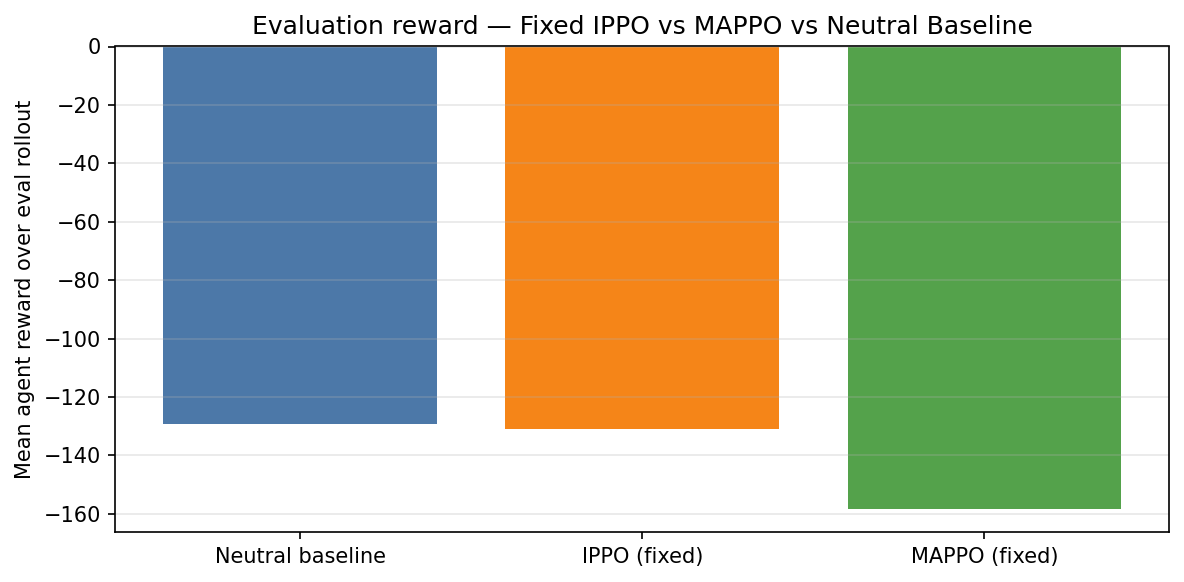

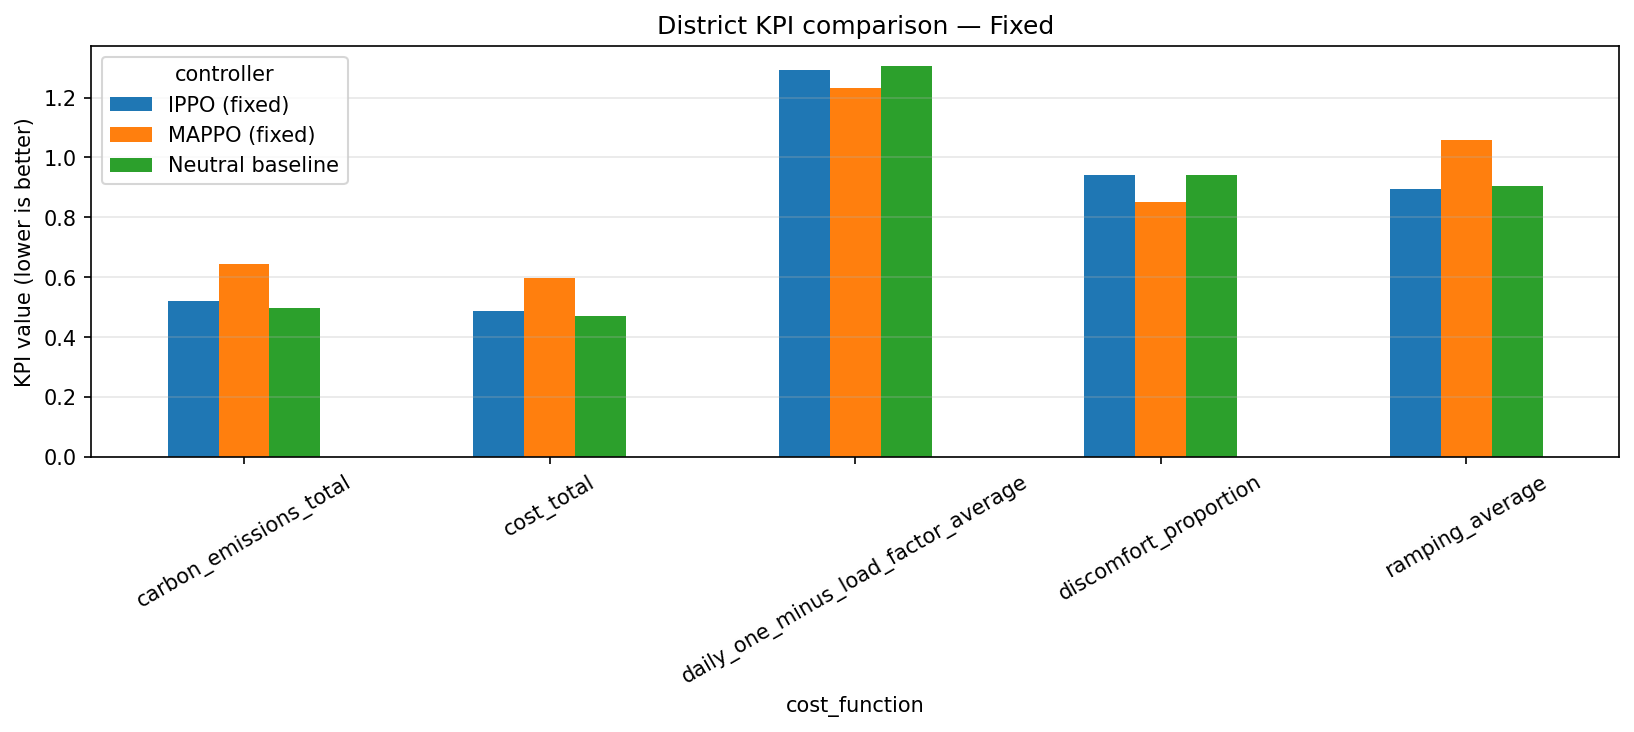

controller,IPPO (fixed),MAPPO (fixed),Neutral baseline
cost_function,,,
carbon_emissions_total,0.520591,0.642816,0.498099
cost_total,0.488357,0.599177,0.469667
daily_one_minus_load_factor_average,1.291030,1.233309,1.306513
discomfort_proportion,0.941384,0.851984,0.941556
ramping_average,0.894413,1.058204,0.904719


In [17]:
# Load per-algorithm history from saved CSVs if current run loaded from checkpoint
_loaded_histories = []
for _algo, _hist_var in [("IPPO", ippo_history), ("MAPPO", mappo_history)]:
    if not _hist_var.empty and "algorithm" in _hist_var.columns:
        _loaded_histories.append(_hist_var)
    else:
        _csv = results_dir / f"{_algo.lower()}_history.csv"
        if _csv.exists():
            _loaded_histories.append(pd.read_csv(_csv))

history = (pd.concat(_loaded_histories, ignore_index=True)
           if _loaded_histories else pd.DataFrame())
history.to_csv(results_dir / "training_history.csv", index=False)

if not history.empty and "algorithm" in history.columns and "env_steps" in history.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for algo, grp in history.groupby("algorithm"):
        axes[0].plot(grp["env_steps"], grp["mean_rollout_reward"],  lw=2, label=algo)
        axes[1].plot(grp["env_steps"], grp["mean_policy_loss"],     lw=2, label=algo)
        axes[2].plot(grp["env_steps"], grp["mean_value_loss"],      lw=2, label=algo)
    axes[0].set_title("Training reward"); axes[0].set_ylabel("Mean rollout reward")
    axes[1].set_title("Policy loss")
    axes[2].set_title("Value loss (should be stable with clipping)")
    for ax in axes:
        ax.set_xlabel("Environment steps"); ax.grid(alpha=0.3); ax.legend()
    plt.suptitle("Fixed IPPO vs MAPPO — Training Curves", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(results_dir / "training_curves_fixed.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(results_dir / "training_curves_fixed.png")))
else:
    print("Training history not available (models loaded from checkpoint; training curves skipped).")

# Evaluation bar chart
fig2, ax2 = plt.subplots(figsize=(8, 4))
plot_df = eval_df.sort_values("mean_agent_reward", ascending=False)
colors  = ["#4C78A8", "#F58518", "#54A24B"][:len(plot_df)]
ax2.bar(plot_df["controller"], plot_df["mean_agent_reward"], color=colors)
ax2.set_title("Evaluation reward — Fixed IPPO vs MAPPO vs Neutral Baseline")
ax2.set_ylabel("Mean agent reward over eval rollout")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "eval_reward_fixed.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
display(Image(filename=str(results_dir / "eval_reward_fixed.png")))

# KPI grouped bar chart
if {"cost_function", "value"}.issubset(kpi_df.columns):
    pivot = kpi_df.pivot_table(index="cost_function", columns="controller",
                                values="value", aggfunc="mean")
    ax3 = pivot.plot(kind="bar", figsize=(11, 5), rot=30)
    ax3.set_title("District KPI comparison — Fixed")
    ax3.set_ylabel("KPI value (lower is better)")
    ax3.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir / "kpi_comparison_fixed.png", dpi=150, bbox_inches="tight")
    plt.close(ax3.figure)
    display(Image(filename=str(results_dir / "kpi_comparison_fixed.png")))
    display(pivot)


## 9 · Interpreting the Results

With all fixes applied the key things to check are:

1. **Value loss** in the training curves should now be notably *more stable* than
   the original (which oscillated 24–47 in the last quarter).  Value clipping
   (Fix 6) and observation normalization (Fix 5) are the main contributors.

2. **IPPO reward signal** is now per-building (`local_individual`), so buildings
   with high cooling load or poor battery management will show distinctly
   different reward trajectories from low-demand buildings — credit assignment
   is working.

3. **MAPPO** uses the shared district reward as intended and its centralized
   critic should show lower variance because normalized global state (180 dims)
   is much better conditioned than raw features spanning wildly different scales.

4. **UAE evaluation** — run `evaluate_controller("UAE", ..., "uae_weighted")` with
   the temperature-shifted schema for zero-shot transfer once the base policies
   are satisfactory.

For publication-quality results: run with at least 3 random seeds, increase
`total_env_steps` to 500 K+, and report mean ± std across seeds.
